In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Figure 1

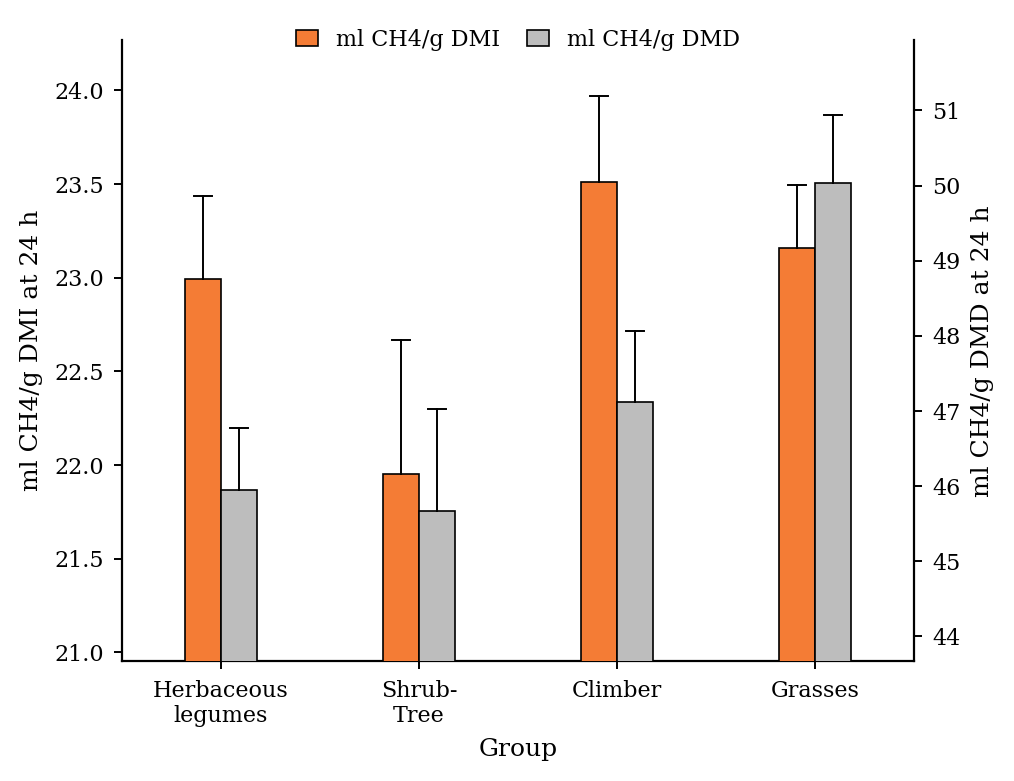

In [69]:
# =========================================================
# Load CSV data
# =========================================================
df = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_05_07_methane_paper/figure_1.csv')

# =========================================================
# Rename groups to match publication style
# =========================================================
group_mapping = {
    "Herbaceous_legume": "Herbaceous\nlegumes",
    "Shrub": "Shrub-\nTree",
    "Tree": "Shrub-\nTree",
    "Climber": "Climber",
    "Grass": "Grasses"
}

df["group"] = df["group"].replace(group_mapping)

# =========================================================
# Group order
# =========================================================
groups = [
    "Herbaceous\nlegumes",
    "Shrub-\nTree",
    "Climber",
    "Grasses"
]

# =========================================================
# Calculate means and SEM
# =========================================================
summary = df.groupby("group").agg(
    dmi_mean=("CH4_in_24h", "mean"),
    dmi_sem=("CH4_in_24h", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    dmd_mean=("CH4_DMD_24h", "mean"),
    dmd_sem=("CH4_DMD_24h", lambda x: x.std(ddof=1) / np.sqrt(len(x)))
).reindex(groups)

# =========================================================
# Extract values
# =========================================================
dmi_mean = summary["dmi_mean"].values
dmi_sem  = summary["dmi_sem"].values

dmd_mean = summary["dmd_mean"].values
dmd_sem  = summary["dmd_sem"].values

# =========================================================
# Figure configuration
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8
})

x = np.arange(len(groups))
width = 0.18

fig, ax1 = plt.subplots(figsize=(5.5, 4.2), dpi=200)

# White background
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

# =========================================================
# Secondary y-axis
# =========================================================
ax2 = ax1.twinx()

# Transparent secondary axis background
ax2.patch.set_alpha(0)

# Hide secondary bottom spine
ax2.spines['bottom'].set_visible(False)

# =========================================================
# Bar plots
# =========================================================
bars1 = ax1.bar(
    x - width/2,
    dmi_mean,
    width=width,
    color='#f47c35',
    edgecolor='black',
    linewidth=0.6,
    label='ml CH4/g DMI',
    zorder=3
)

bars2 = ax2.bar(
    x + width/2,
    dmd_mean,
    width=width,
    color='#bdbdbd',
    edgecolor='black',
    linewidth=0.6,
    label='ml CH4/g DMD',
    zorder=2
)

# =========================================================
# Draw only upper whiskers (SEM)
# =========================================================
cap_width = 0.045

# Left whiskers
for i in range(len(x)):

    xpos = x[i] - width/2
    y0 = dmi_mean[i]
    y1 = y0 + dmi_sem[i]

    ax1.plot(
        [xpos, xpos],
        [y0, y1],
        color='black',
        lw=0.7,
        zorder=4
    )

    ax1.plot(
        [xpos - cap_width, xpos + cap_width],
        [y1, y1],
        color='black',
        lw=0.7,
        zorder=4
    )

# Right whiskers
for i in range(len(x)):

    xpos = x[i] + width/2
    y0 = dmd_mean[i]
    y1 = y0 + dmd_sem[i]

    ax2.plot(
        [xpos, xpos],
        [y0, y1],
        color='black',
        lw=0.7,
        zorder=4
    )

    ax2.plot(
        [xpos - cap_width, xpos + cap_width],
        [y1, y1],
        color='black',
        lw=0.7,
        zorder=4
    )

# =========================================================
# Axis limits
# =========================================================
ax1.set_ylim(
    min(dmi_mean) - 1,
    max(dmi_mean + dmi_sem) + 0.3
)

ax2.set_ylim(
    min(dmd_mean) - 2,
    max(dmd_mean + dmd_sem) + 1
)

ax1.set_xlim(-0.5, len(groups)-0.5)

# =========================================================
# Labels
# =========================================================
ax1.set_xticks(x)

ax1.set_xticklabels(
    groups,
    fontsize=8,
    color='black'
)

ax1.set_xlabel(
    'Group',
    fontsize=9,
    color='black'
)

ax1.set_ylabel(
    'ml CH4/g DMI at 24 h',
    fontsize=9,
    color='black'
)

ax2.set_ylabel(
    'ml CH4/g DMD at 24 h',
    fontsize=9,
    color='black'
)

# =========================================================
# Spine styling
# =========================================================
# Remove top spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Left Y-axis
ax1.spines['left'].set_visible(True)
ax1.spines['left'].set_color('black')
ax1.spines['left'].set_linewidth(0.8)

# Bottom X-axis
ax1.spines['bottom'].set_visible(True)
ax1.spines['bottom'].set_color('black')
ax1.spines['bottom'].set_linewidth(0.8)
ax1.spines['bottom'].set_position(('outward', 0))

# Right Y-axis
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('black')
ax2.spines['right'].set_linewidth(0.8)

# Hide duplicate left spine
ax2.spines['left'].set_visible(False)

# =========================================================
# Remove gridlines
# =========================================================
ax1.grid(False)
ax2.grid(False)

# =========================================================
# Tick styling
# =========================================================
ax1.tick_params(
    axis='x',
    direction='out',
    length=3,
    width=0.7,
    colors='black',
    labelsize=8
)

ax1.tick_params(
    axis='y',
    direction='out',
    length=3,
    width=0.7,
    colors='black',
    labelsize=8
)

ax2.tick_params(
    axis='y',
    direction='out',
    length=3,
    width=0.7,
    colors='black',
    labelsize=8
)

# =========================================================
# Legend
# =========================================================
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    frameon=False,
    fontsize=8,
    handlelength=1.0,
    columnspacing=1.2
)

# =========================================================
# Layout
# =========================================================
plt.subplots_adjust(
    left=0.14,
    right=0.86,
    bottom=0.14,
    top=0.88
)

# =========================================================
# Optional export
# =========================================================
plt.savefig("/content/drive/MyDrive/lmf/output/2026_05_07_methane_paper/figure_1.tiff", dpi=600, bbox_inches='tight')

plt.show()

# Figure 2

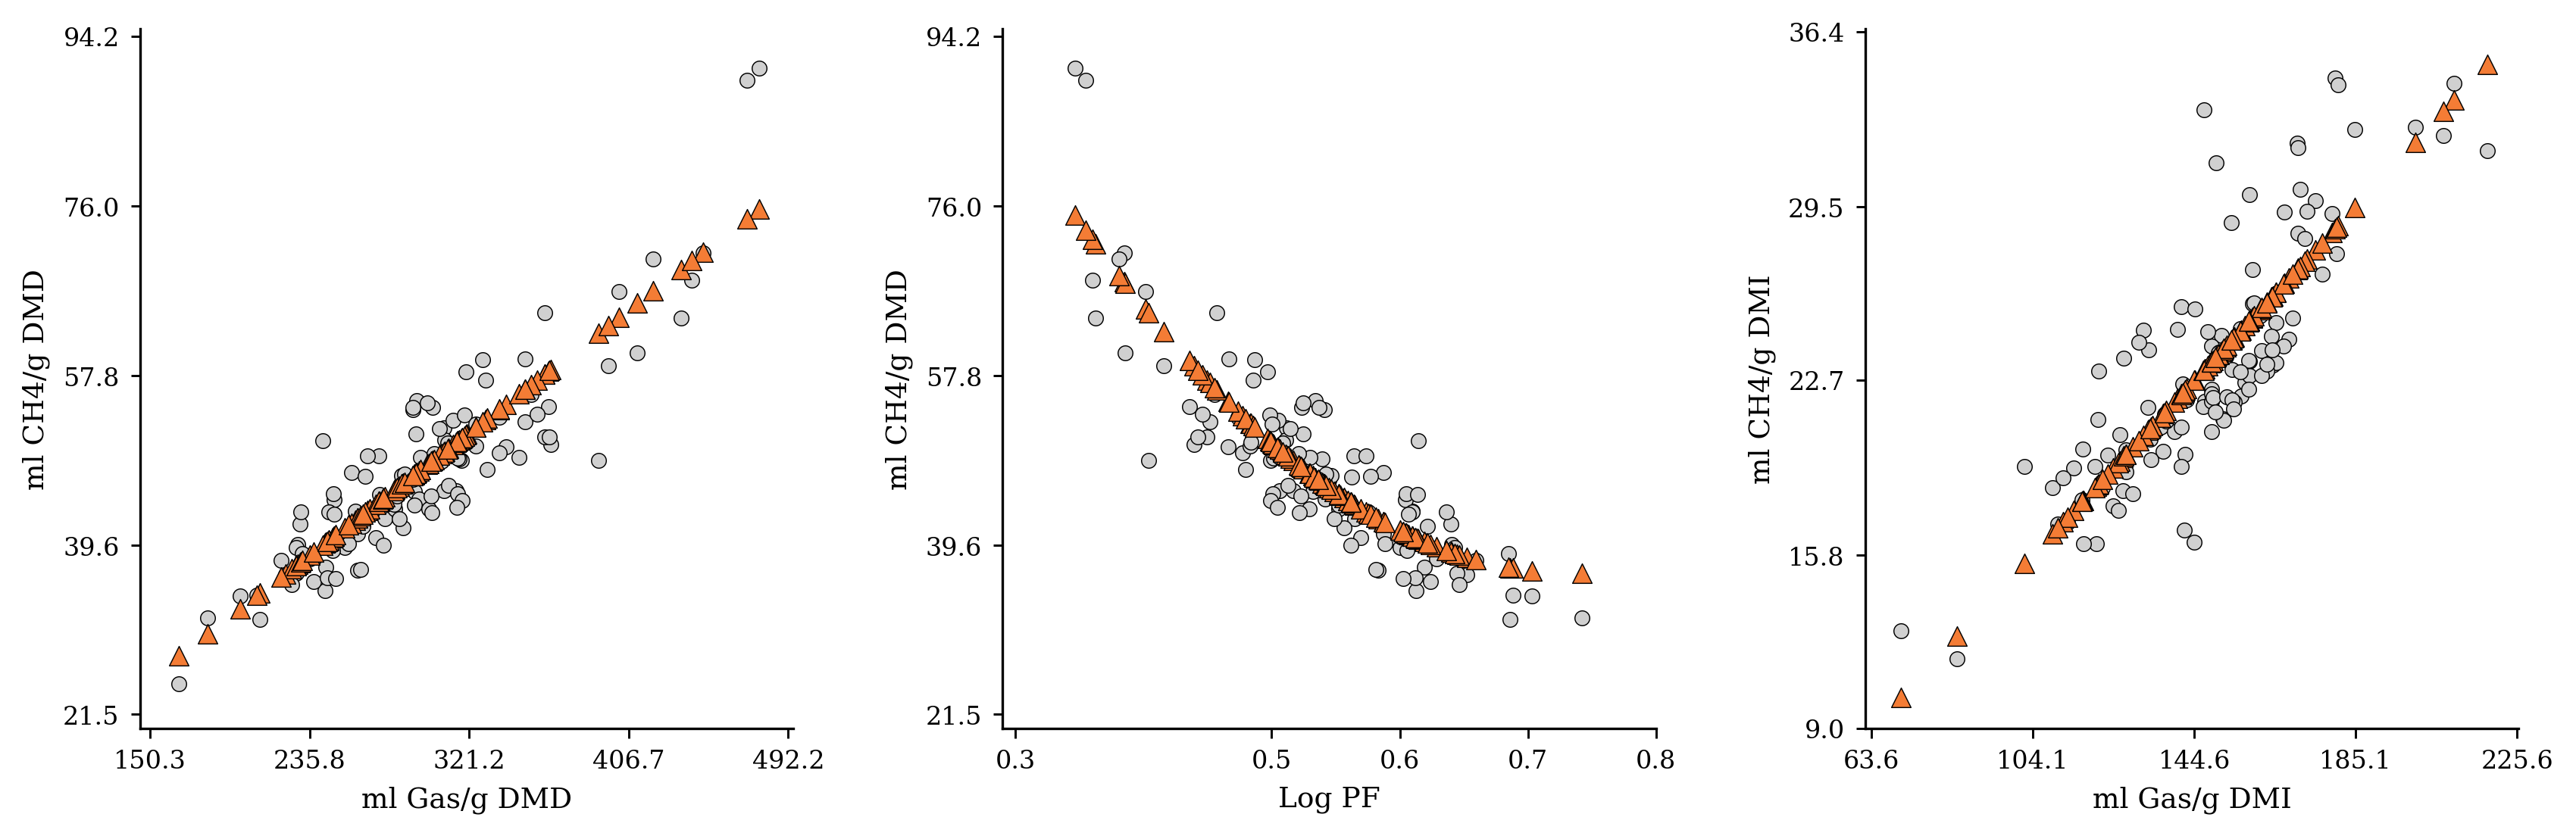

In [70]:
# =========================================================
# Load dataset
# =========================================================
df = pd.read_csv("/content/drive/MyDrive/lmf/data/2026_05_07_methane_paper/figure_2.csv")

# =========================================================
# Decimal points formatter
# =========================================================
dot_formatter = FuncFormatter(lambda x, pos: f"{x:.1f}")

# =========================================================
# Publication-style aesthetics
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8
})

# =========================================================
# Figure configuration
# =========================================================
fig, axes = plt.subplots(
    1, 3,
    figsize=(11.5, 3.8),
    dpi=300
)

# White background
fig.patch.set_facecolor('white')

# =========================================================
# Common colors
# =========================================================
orange = '#f47c35'
gray = '#d0d0d0'

# =========================================================
# PANEL 1
# =========================================================
ax = axes[0]

ax.set_facecolor('white')

# Observed
ax.scatter(
    df["gas_DMD"],
    df["Obs_CH4_DMD"],
    s=22,
    facecolors=gray,
    edgecolors='black',
    linewidths=0.35,
    zorder=2
)

# Predicted
ax.scatter(
    df["gas_DMD"],
    df["predCH4_Gas_DMD"],
    s=38,
    marker='^',
    color=orange,
    edgecolors='black',
    linewidths=0.35,
    zorder=3
)

# Axis limits
ax.set_xlim(145, 495)
ax.set_ylim(20, 95)

# Ticks
ax.set_xticks([150.3, 235.8, 321.2, 406.7, 492.2])
ax.set_yticks([21.5, 39.6, 57.8, 76.0, 94.2])

# Labels
ax.set_xlabel('ml Gas/g DMD', fontsize=9, color='black')
ax.set_ylabel('ml CH4/g DMD', fontsize=9, color='black')

# Decimal points
ax.xaxis.set_major_formatter(dot_formatter)
ax.yaxis.set_major_formatter(dot_formatter)

# =========================================================
# PANEL 2
# =========================================================
ax = axes[1]

ax.set_facecolor('white')

# Observed
ax.scatter(
    df["log_FP"],
    df["Obs_CH4_DMD.1"],
    s=22,
    facecolors=gray,
    edgecolors='black',
    linewidths=0.35,
    zorder=2
)

# Predicted
ax.scatter(
    df["log_FP"],
    df["predCH4_log_FP"],
    s=38,
    marker='^',
    color=orange,
    edgecolors='black',
    linewidths=0.35,
    zorder=3
)

# Axis limits
ax.set_xlim(0.29, 0.80)
ax.set_ylim(20, 95)

# Ticks
ax.set_xticks([0.3, 0.5, 0.6, 0.7, 0.8])
ax.set_yticks([21.5, 39.6, 57.8, 76.0, 94.2])

# Labels
ax.set_xlabel('Log PF', fontsize=9, color='black')
ax.set_ylabel('ml CH4/g DMD', fontsize=9, color='black')

# Decimal points
ax.xaxis.set_major_formatter(dot_formatter)
ax.yaxis.set_major_formatter(dot_formatter)

# =========================================================
# PANEL 3
# =========================================================
ax = axes[2]

ax.set_facecolor('white')

# Observed
ax.scatter(
    df["gas_DMI"],
    df["Obs_CH4_DMI"],
    s=22,
    facecolors=gray,
    edgecolors='black',
    linewidths=0.35,
    zorder=2
)

# Predicted
ax.scatter(
    df["gas_DMI"],
    df["predCH4_Gas_DMI"],
    s=38,
    marker='^',
    color=orange,
    edgecolors='black',
    linewidths=0.35,
    zorder=3
)

# Axis limits
ax.set_xlim(62, 226)
ax.set_ylim(9, 36.5)

# Ticks
ax.set_xticks([63.6, 104.1, 144.6, 185.1, 225.6])
ax.set_yticks([9.0, 15.8, 22.7, 29.5, 36.4])

# Labels
ax.set_xlabel('ml Gas/g DMI', fontsize=9, color='black')
ax.set_ylabel('ml CH4/g DMI', fontsize=9, color='black')

# Decimal points
ax.xaxis.set_major_formatter(dot_formatter)
ax.yaxis.set_major_formatter(dot_formatter)

# =========================================================
# Shared aesthetics
# =========================================================
for ax in axes:

    # Remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Left spine
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(0.8)

    # Bottom spine
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(0.8)

    # Remove grid
    ax.grid(False)

    # Force black axis text
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

    # Tick styling
    ax.tick_params(
        axis='both',
        direction='out',
        length=3,
        width=0.7,
        colors='black',
        labelsize=8
    )

# =========================================================
# Layout
# =========================================================
plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.16,
    top=0.97,
    wspace=0.32
)

# =========================================================
# Export (optional)
# =========================================================
plt.savefig("/content/drive/MyDrive/lmf/output/2026_05_07_methane_paper/figure_2.tiff", dpi=600, bbox_inches='tight')

plt.show()

# Figure 3

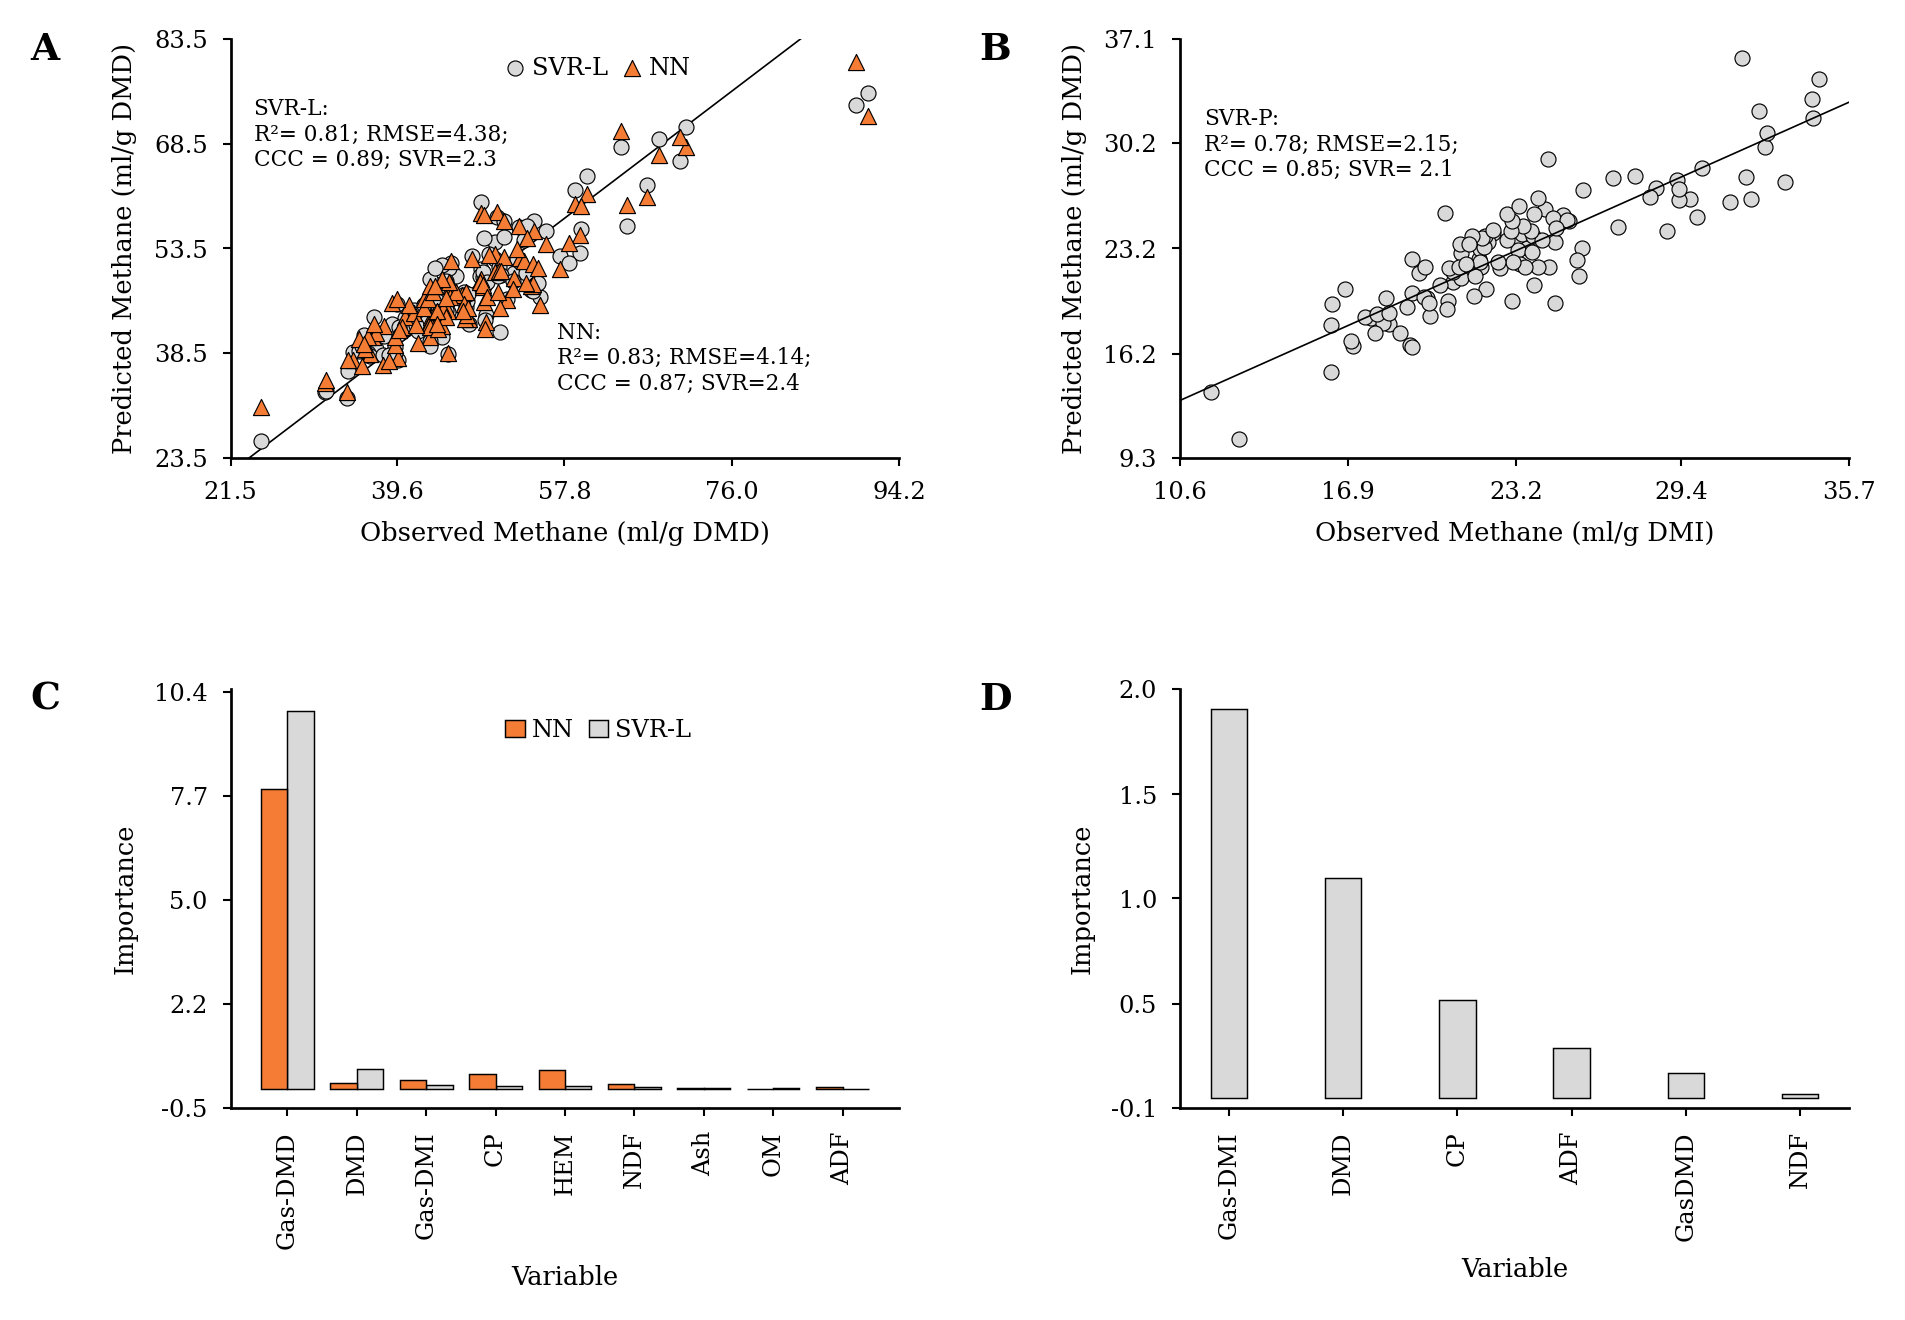

In [71]:
# =========================================================
# Load dataset
# =========================================================
df = pd.read_csv("/content/drive/MyDrive/lmf/data/2026_05_07_methane_paper/figure_3.csv")

# =========================================================
# Decimal formatter with POINTS
# =========================================================
dot_formatter = FuncFormatter(lambda x, pos: f"{x:.1f}".replace(",", "."))

# =========================================================
# Publication-style aesthetics
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 6.3
})

# =========================================================
# Figure configuration
# =========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(6.2, 4.4),
    dpi=300
)

fig.patch.set_facecolor("white")

# =========================================================
# Colors
# =========================================================
orange = "#f47c35"
gray = "#d9d9d9"

# =========================================================
# Font sizes
# =========================================================
label_fs  = 6.2
tick_fs   = 5.8
text_fs   = 5.2
legend_fs = 5.8
panel_fs  = 9
xtick_bar_fs = 5.6

# =========================================================
# PANEL A
# =========================================================
ax = axes[0, 0]

# Scatter points
ax.scatter(
    df["obs_CH4_DMD"],
    df["pred_SVRL"],
    s=13,
    facecolors=gray,
    edgecolors="black",
    linewidths=0.28,
    label="SVR-L",
    zorder=2
)

ax.scatter(
    df["obs_CH4_DMD"],
    df["pred_NN"],
    s=15,
    marker="^",
    color=orange,
    edgecolors="black",
    linewidths=0.28,
    label="NN",
    zorder=3
)

# 1:1 line
xmin, xmax = 21.5, 94.2

ax.plot(
    [xmin, xmax],
    [xmin, xmax],
    color="black",
    linewidth=0.40,
    zorder=1
)

# Limits
ax.set_xlim(21.5, 94.2)
ax.set_ylim(23.5, 83.5)

# Ticks
ax.set_xticks([21.5, 39.6, 57.8, 76.0, 94.2])
ax.set_yticks([23.5, 38.5, 53.5, 68.5, 83.5])

# Labels
ax.set_xlabel(
    "Observed Methane (ml/g DMD)",
    fontsize=label_fs,
    color="black"
)

ax.set_ylabel(
    "Predicted Methane (ml/g DMD)",
    fontsize=label_fs,
    color="black"
)

# Decimal format
ax.xaxis.set_major_formatter(dot_formatter)
ax.yaxis.set_major_formatter(dot_formatter)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.55, 1.01),
    ncol=2,
    frameon=False,
    fontsize=legend_fs,
    handlelength=0.8,
    handletextpad=0.3,
    columnspacing=0.6
)

# Statistics text
ax.text(
    24,
    75,
    "SVR-L:\nR²= 0.81; RMSE=4.38;\nCCC = 0.89; SVR=2.3",
    fontsize=text_fs,
    ha="left",
    va="top"
)

ax.text(
    57,
    43,
    "NN:\nR²= 0.83; RMSE=4.14;\nCCC = 0.87; SVR=2.4",
    fontsize=text_fs,
    ha="left",
    va="top"
)

# Panel letter
ax.text(
    -0.30,
    1.02,
    "A",
    transform=ax.transAxes,
    fontsize=panel_fs,
    fontweight="bold",
    va="top"
)

# =========================================================
# PANEL B
# =========================================================
ax = axes[0, 1]

# Scatter
ax.scatter(
    df["obs_CH4_in"],
    df["predicho"],
    s=13,
    facecolors=gray,
    edgecolors="black",
    linewidths=0.28,
    zorder=2
)

# Regression line
coef = np.polyfit(df["obs_CH4_in"], df["predicho"], 1)

xline = np.linspace(10.6, 35.7, 100)
yline = coef[0] * xline + coef[1]

ax.plot(
    xline,
    yline,
    color="black",
    linewidth=0.40
)

# Limits
ax.set_xlim(10.6, 35.7)
ax.set_ylim(9.3, 37.1)

# Ticks
ax.set_xticks([10.6, 16.9, 23.2, 29.4, 35.7])
ax.set_yticks([9.3, 16.2, 23.2, 30.2, 37.1])

# Labels
ax.set_xlabel(
    "Observed Methane (ml/g DMI)",
    fontsize=label_fs,
    color="black"
)

ax.set_ylabel(
    "Predicted Methane (ml/g DMD)",
    fontsize=label_fs,
    color="black"
)

# Decimal format
ax.xaxis.set_major_formatter(dot_formatter)
ax.yaxis.set_major_formatter(dot_formatter)

# Statistics text
ax.text(
    11.5,
    32.5,
    "SVR-P:\nR²= 0.78; RMSE=2.15;\nCCC = 0.85; SVR= 2.1",
    fontsize=text_fs,
    ha="left",
    va="top"
)

# Panel letter
ax.text(
    -0.30,
    1.02,
    "B",
    transform=ax.transAxes,
    fontsize=panel_fs,
    fontweight="bold",
    va="top"
)

# =========================================================
# PANEL C
# =========================================================
ax = axes[1, 0]

imp = df[["Model", "Variable", "Importance"]].dropna()

svr = imp[imp["Model"] == "SVR-L"]
nn  = imp[imp["Model"] == "NN"]

variables = svr["Variable"].values

x = np.arange(len(variables))
width = 0.38

# Bars
ax.bar(
    x - width/2,
    nn["Importance"],
    width=width,
    color=orange,
    edgecolor="black",
    linewidth=0.35,
    label="NN",
    zorder=3
)

ax.bar(
    x + width/2,
    svr["Importance"],
    width=width,
    color=gray,
    edgecolor="black",
    linewidth=0.35,
    label="SVR-L",
    zorder=2
)

# Labels
ax.set_xticks(x)

ax.set_xticklabels(
    ["Gas-DMD", "DMD", "Gas-DMI", "CP", "HEM",
     "NDF", "Ash", "OM", "ADF"],
    rotation=90,
    fontsize=xtick_bar_fs
)

ax.set_ylabel(
    "Importance",
    fontsize=label_fs,
    color="black"
)

ax.set_xlabel(
    "Variable",
    fontsize=label_fs,
    color="black"
)

# Limits
ax.set_ylim(-0.5, 10.5)

# Ticks
ax.set_yticks([-0.5, 2.23, 4.96, 7.69, 10.42])

# Decimal format
ax.yaxis.set_major_formatter(dot_formatter)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.55, 0.98),
    ncol=2,
    frameon=False,
    fontsize=legend_fs,
    handlelength=0.8,
    handletextpad=0.3,
    columnspacing=0.6
)

# Panel letter
ax.text(
    -0.30,
    1.02,
    "C",
    transform=ax.transAxes,
    fontsize=panel_fs,
    fontweight="bold",
    va="top"
)

# =========================================================
# PANEL D
# =========================================================
ax = axes[1, 1]

imp2 = df[["Variable.1", "Importance.1"]].dropna()

x = np.arange(len(imp2))

# Bars
ax.bar(
    x,
    imp2["Importance.1"],
    width=0.32,
    color=gray,
    edgecolor="black",
    linewidth=0.35,
    zorder=3
)

# Labels
ax.set_xticks(x)

ax.set_xticklabels(
    ["Gas-DMI", "DMD", "CP", "ADF", "GasDMD", "NDF"],
    rotation=90,
    fontsize=xtick_bar_fs
)

ax.set_ylabel(
    "Importance",
    fontsize=label_fs,
    color="black"
)

ax.set_xlabel(
    "Variable",
    fontsize=label_fs,
    color="black"
)

# Limits
ax.set_ylim(-0.05, 2.05)

# Ticks
ax.set_yticks([-0.05, 0.47, 1.00, 1.52, 2.05])

# Decimal format
ax.yaxis.set_major_formatter(dot_formatter)

# Panel letter
ax.text(
    -0.30,
    1.02,
    "D",
    transform=ax.transAxes,
    fontsize=panel_fs,
    fontweight="bold",
    va="top"
)

# =========================================================
# Shared aesthetics
# =========================================================
for ax in axes.flat:

    ax.set_facecolor("white")

    # Remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Spine style
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.spines["left"].set_linewidth(0.65)
    ax.spines["bottom"].set_linewidth(0.65)

    # No grid
    ax.grid(False)

    # Tick style
    ax.tick_params(
        axis="both",
        direction="out",
        length=2.0,
        width=0.50,
        colors="black",
        labelsize=tick_fs
    )

# =========================================================
# Layout
# =========================================================
plt.subplots_adjust(
    left=0.11,
    right=0.98,
    bottom=0.15,
    top=0.96,
    wspace=0.42,
    hspace=0.55
)

# =========================================================
# Export
# =========================================================
plt.savefig("/content/drive/MyDrive/lmf/output/2026_05_07_methane_paper/figure_3.tiff", dpi=600, bbox_inches='tight')

plt.show()